In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

In [ ]:
PRED_DIR = Path("artifacts/predictions")
OUT_DIR = Path("artifacts/reports/bootstrap_samples_f1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

B = 10_000
RANDOM_STATE = 42

QUESTION_GROUPS = {
    "truly_open": [f"dataset{i}" for i in range(1, 7)],
    "seemingly_open": [f"dataset{i}" for i in range(7, 11)],
}

CLASSIC_MODELS = [
    "logistic_regression",
    "naive_bayes",
    "svm",
    "random_forest",
    "gradient_boosting",
]

PAIRED_COMPARISONS = {
    "classic_ml": {
        "baseline": "logistic_regression",
        "models": ["naive_bayes", "svm", "random_forest", "gradient_boosting"],
    },
    "cnn_rnn": {
        "baseline": "rnn",
        "models": ["cnn"],
    },
}

ENCODER_GIGACHAT_MODELS = {
    "encoder",
    "gigachat_zero_shot_codebook",
    "gigachat_retrieval_few_shot_codebook",
    "gigachat_in_context_100_codebook",
}
ENCODER_GIGACHAT_BASELINE = "encoder"

MODEL_LABELS = {
    "logistic_regression": "LogReg",
    "naive_bayes": "NB",
    "svm": "SVM",
    "random_forest": "RF",
    "gradient_boosting": "GB",
    "rnn": "RNN",
    "cnn": "CNN",
    "encoder": "Encoder",
    "gigachat_zero_shot_codebook": "GigaChat Zero-shot",
    "gigachat_retrieval_few_shot_codebook": "Retrieval Few-shot",
    "gigachat_in_context_100_codebook": "ICL",
}


In [ ]:
def model_label(model):
    return MODEL_LABELS.get(model, model)

In [ ]:
def sample_f1_per_object(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    intersection = (y_true & y_pred).sum(axis=1)
    denominator = y_true.sum(axis=1) + y_pred.sum(axis=1)
    return np.divide(
        2 * intersection,
        denominator,
        out=np.zeros(len(denominator), dtype=float),
        where=denominator != 0,
    )

In [ ]:
def question_group_for(dataset):
    for group, datasets in QUESTION_GROUPS.items():
        if dataset in datasets:
            return group

In [ ]:
def family_for(model):
    if model in CLASSIC_MODELS:
        return "classic_ml"
    if model in {"rnn", "cnn"}:
        return "cnn_rnn"
    return "encoder_gigachat"

In [ ]:
preds = {}
truths = {}
rows = []

for path in sorted(PRED_DIR.rglob("*.npz")):
    dataset = [part for part in path.parts if part.startswith("dataset")][0]
    model = path.stem
    data = np.load(path, allow_pickle=True)
    f1 = sample_f1_per_object(data["y_true"], data["y_pred"])

    preds[(dataset, model)] = f1
    truths[(dataset, model)] = data["y_true"]
    rows.append({
        "question_group": question_group_for(dataset),
        "family": family_for(model),
        "dataset": dataset,
        "model": model,
        "model_name": model_label(model),
        "n": len(f1),
        "samples_f1": f1.mean(),
    })

scores = pd.DataFrame(rows).sort_values(["question_group", "family", "model", "dataset"])
scores

,question_group,family,dataset,model,model_name,n,samples_f1
5,seemingly_open,classic_ml,dataset10,gradient_boosting,GB,628,0.911071
35,seemingly_open,classic_ml,dataset7,gradient_boosting,GB,629,0.909872
40,seemingly_open,classic_ml,dataset8,gradient_boosting,GB,629,0.928590
45,seemingly_open,classic_ml,dataset9,gradient_boosting,GB,629,0.902496
6,seemingly_open,classic_ml,dataset10,logistic_regression,LogReg,628,0.903435
...,...,...,...,...,...,...,...
66,truly_open,encoder_gigachat,dataset2,gigachat_zero_shot_codebook,GigaChat Zero-shot,86,0.034884
72,truly_open,encoder_gigachat,dataset3,gigachat_zero_shot_codebook,GigaChat Zero-shot,1318,0.131663
78,truly_open,encoder_gigachat,dataset4,gigachat_zero_shot_codebook,GigaChat Zero-shot,1402,0.089120
84,truly_open,encoder_gigachat,dataset5,gigachat_zero_shot_codebook,GigaChat Zero-shot,630,0.307187


In [ ]:
group_scores = (
    scores
    .groupby(["question_group", "family", "model"], as_index=False)
    .agg(samples_f1=("samples_f1", "mean"))
    .sort_values(["question_group", "family", "model"])
)

group_scores

,question_group,family,model,samples_f1
0,seemingly_open,classic_ml,gradient_boosting,0.913007
1,seemingly_open,classic_ml,logistic_regression,0.921543
2,seemingly_open,classic_ml,naive_bayes,0.843237
3,seemingly_open,classic_ml,random_forest,0.917823
4,seemingly_open,classic_ml,svm,0.929391
5,seemingly_open,cnn_rnn,cnn,0.918015
6,seemingly_open,cnn_rnn,rnn,0.924503
7,seemingly_open,encoder_gigachat,encoder,0.598648
8,seemingly_open,encoder_gigachat,gigachat_in_context_100_codebook,0.463985
9,seemingly_open,encoder_gigachat,gigachat_retrieval_few_shot_codebook,0.260964


In [ ]:
results = []

for question_group, datasets in QUESTION_GROUPS.items():
    for family, settings in PAIRED_COMPARISONS.items():
        baseline = settings["baseline"]
        models = settings["models"]
        alpha = 0.05 / len(models)

        for model in models:
            rng = np.random.default_rng(RANDOM_STATE)
            observed_deltas = []
            boot_deltas = np.empty(B)

            for dataset in datasets:
                model_f1 = preds[(dataset, model)]
                baseline_f1 = preds[(dataset, baseline)]
                observed_deltas.append(model_f1.mean() - baseline_f1.mean())

            for b in range(B):
                dataset_deltas = []

                for dataset in datasets:
                    model_f1 = preds[(dataset, model)]
                    baseline_f1 = preds[(dataset, baseline)]
                    idx = rng.integers(0, len(model_f1), len(model_f1))
                    dataset_deltas.append(model_f1[idx].mean() - baseline_f1[idx].mean())

                boot_deltas[b] = np.mean(dataset_deltas)

            ci_low, ci_high = np.quantile(boot_deltas, [alpha / 2, 1 - alpha / 2])

            results.append({
                "question_group": question_group,
                "family": family,
                "model": model,
                "model_name": model_label(model),
                "baseline": baseline,
                "baseline_name": model_label(baseline),
                "delta_samples_f1": np.mean(observed_deltas),
                "ci_low": ci_low,
                "ci_high": ci_high,
                "alpha_bonferroni": alpha,
                "significant": ci_low > 0 or ci_high < 0,
            })

paired_bootstrap = pd.DataFrame(results).sort_values(["question_group", "family", "model"])
paired_bootstrap


,question_group,family,model,model_name,baseline,baseline_name,delta_samples_f1,ci_low,ci_high,alpha_bonferroni,significant
8,seemingly_open,classic_ml,gradient_boosting,GB,logistic_regression,LogReg,-0.008536,-0.016751,-0.000320,0.0125,True
5,seemingly_open,classic_ml,naive_bayes,NB,logistic_regression,LogReg,-0.078306,-0.089363,-0.067327,0.0125,True
7,seemingly_open,classic_ml,random_forest,RF,logistic_regression,LogReg,-0.003721,-0.010902,0.003470,0.0125,False
6,seemingly_open,classic_ml,svm,SVM,logistic_regression,LogReg,0.007847,0.002558,0.013155,0.0125,True
9,seemingly_open,cnn_rnn,cnn,CNN,rnn,RNN,-0.006488,-0.011816,-0.001035,0.0500,True
3,truly_open,classic_ml,gradient_boosting,GB,logistic_regression,LogReg,-0.093615,-0.114486,-0.073119,0.0125,True
0,truly_open,classic_ml,naive_bayes,NB,logistic_regression,LogReg,-0.051789,-0.072897,-0.030668,0.0125,True
2,truly_open,classic_ml,random_forest,RF,logistic_regression,LogReg,-0.044940,-0.065190,-0.024400,0.0125,True
1,truly_open,classic_ml,svm,SVM,logistic_regression,LogReg,0.012547,-0.000860,0.026364,0.0125,False
4,truly_open,cnn_rnn,cnn,CNN,rnn,RNN,0.039131,0.022592,0.055396,0.0500,True


In [ ]:
def same_test_split(dataset, model, baseline):
    y_model = truths[(dataset, model)]
    y_baseline = truths[(dataset, baseline)]
    return y_model.shape == y_baseline.shape and np.array_equal(y_model, y_baseline)

In [ ]:
rows = []
delta_rows = []
models = sorted(model for model in ENCODER_GIGACHAT_MODELS if model != ENCODER_GIGACHAT_BASELINE)
alpha = 0.05 / len(models)

for question_group, datasets in QUESTION_GROUPS.items():
    baseline_scores = [preds[(dataset, ENCODER_GIGACHAT_BASELINE)] for dataset in datasets]

    for model in sorted(ENCODER_GIGACHAT_MODELS):
        rng = np.random.default_rng(RANDOM_STATE)
        per_dataset = [preds[(dataset, model)] for dataset in datasets]
        distribution = np.empty(B)

        for b in range(B):
            means = []
            for f1 in per_dataset:
                idx = rng.integers(0, len(f1), len(f1))
                means.append(f1[idx].mean())
            distribution[b] = np.mean(means)

        ci_low, ci_high = np.quantile(distribution, [0.025, 0.975])
        rows.append({
            "question_group": question_group,
            "family": "encoder_gigachat",
            "model": model,
            "model_name": model_label(model),
            "samples_f1": np.mean([f1.mean() for f1 in per_dataset]),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "n_datasets": len(per_dataset),
            "n_objects": sum(len(f1) for f1 in per_dataset),
        })

        if model == ENCODER_GIGACHAT_BASELINE:
            continue

        rng = np.random.default_rng(RANDOM_STATE)
        delta_distribution = np.empty(B)
        paired_datasets = 0

        for b in range(B):
            deltas = []
            for dataset in datasets:
                model_f1 = preds[(dataset, model)]
                baseline_f1 = preds[(dataset, ENCODER_GIGACHAT_BASELINE)]

                if same_test_split(dataset, model, ENCODER_GIGACHAT_BASELINE):
                    idx = rng.integers(0, len(model_f1), len(model_f1))
                    deltas.append(model_f1[idx].mean() - baseline_f1[idx].mean())
                    if b == 0:
                        paired_datasets += 1
                else:
                    model_idx = rng.integers(0, len(model_f1), len(model_f1))
                    baseline_idx = rng.integers(0, len(baseline_f1), len(baseline_f1))
                    deltas.append(model_f1[model_idx].mean() - baseline_f1[baseline_idx].mean())

            delta_distribution[b] = np.mean(deltas)

        ci_low, ci_high = np.quantile(delta_distribution, [alpha / 2, 1 - alpha / 2])
        delta_rows.append({
            "question_group": question_group,
            "family": "encoder_gigachat",
            "model": model,
            "model_name": model_label(model),
            "baseline": ENCODER_GIGACHAT_BASELINE,
            "baseline_name": model_label(ENCODER_GIGACHAT_BASELINE),
            "delta_samples_f1": np.mean([f1.mean() for f1 in per_dataset]) - np.mean([f1.mean() for f1 in baseline_scores]),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "alpha_bonferroni": alpha,
            "paired_datasets": paired_datasets,
            "significant": ci_low > 0 or ci_high < 0,
        })

encoder_gigachat_ci = pd.DataFrame(rows).sort_values(["question_group", "model"])
encoder_gigachat_delta = pd.DataFrame(delta_rows).sort_values(["question_group", "model"])
encoder_gigachat_delta


,question_group,family,model,model_name,baseline,baseline_name,delta_samples_f1,ci_low,ci_high,alpha_bonferroni,paired_datasets,significant
3,seemingly_open,encoder_gigachat,gigachat_in_context_100_codebook,ICL,encoder,Encoder,-0.134663,-0.168516,-0.099870,0.016667,0,True
4,seemingly_open,encoder_gigachat,gigachat_retrieval_few_shot_codebook,Retrieval Few-shot,encoder,Encoder,-0.337684,-0.369056,-0.305154,0.016667,0,True
5,seemingly_open,encoder_gigachat,gigachat_zero_shot_codebook,GigaChat Zero-shot,encoder,Encoder,-0.424522,-0.456546,-0.392833,0.016667,0,True
0,truly_open,encoder_gigachat,gigachat_in_context_100_codebook,ICL,encoder,Encoder,-0.238462,-0.277373,-0.199323,0.016667,0,True
1,truly_open,encoder_gigachat,gigachat_retrieval_few_shot_codebook,Retrieval Few-shot,encoder,Encoder,-0.326976,-0.364613,-0.288004,0.016667,0,True
2,truly_open,encoder_gigachat,gigachat_zero_shot_codebook,GigaChat Zero-shot,encoder,Encoder,-0.425335,-0.456254,-0.394838,0.016667,0,True


In [ ]:
def plot_bootstrap_ci(df, question_group, family):
    data = df[
        (df["question_group"] == question_group) &
        (df["family"] == family)
    ].copy()
    data = data.sort_values("delta_samples_f1")

    y = np.arange(len(data))
    x = data["delta_samples_f1"].values
    x_low = data["ci_low"].values
    x_high = data["ci_high"].values

    xerr = np.vstack([x - x_low, x_high - x])

    plt.figure(figsize=(9, 0.7 * len(data) + 2))
    plt.errorbar(x, y, xerr=xerr, fmt="o", capsize=4)
    plt.axvline(0, linestyle="--")
    plt.yticks(y, data["model_name"])
    plt.xlim(-0.2, 0.1)
    plt.xlabel("Difference in samples-F1 relative to baseline")
    plt.title(f"{question_group}: {family}")
    plt.tight_layout()
    plt.show()

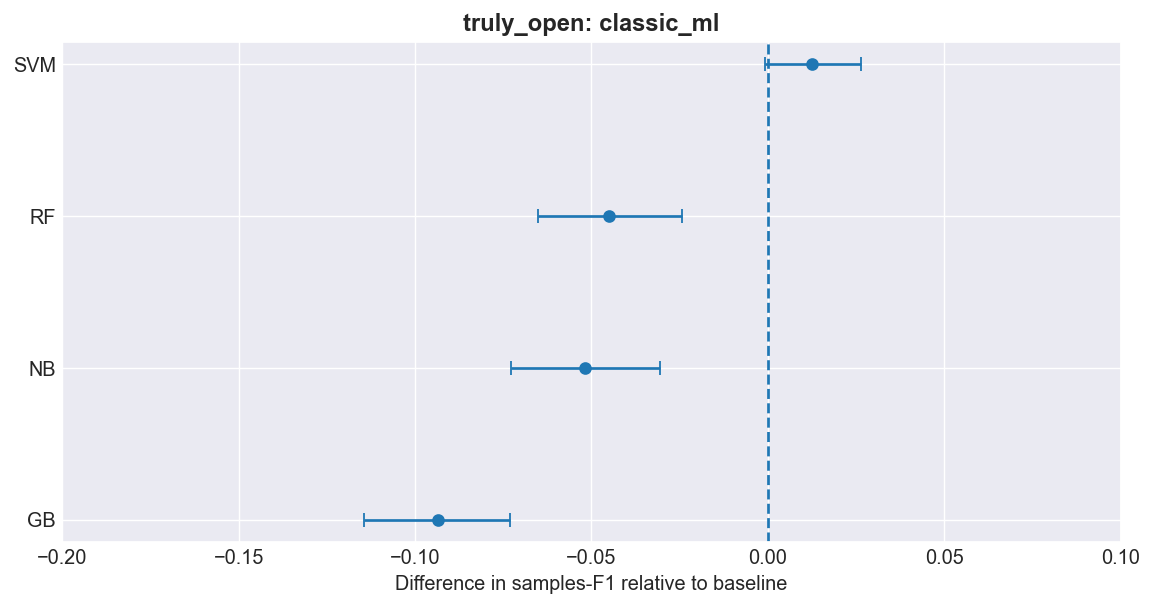

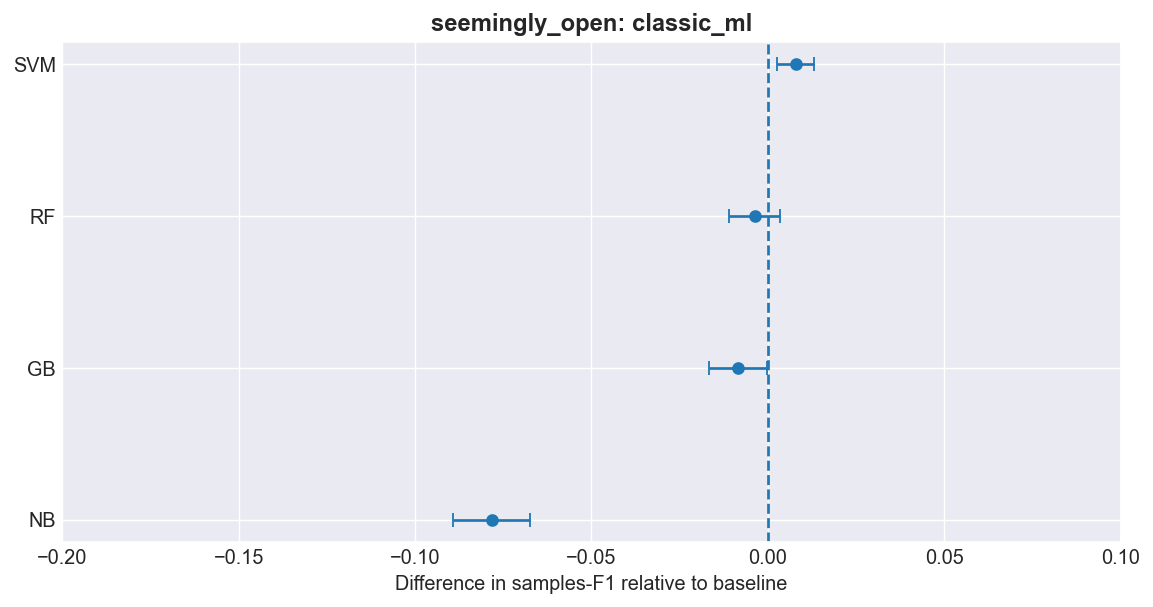

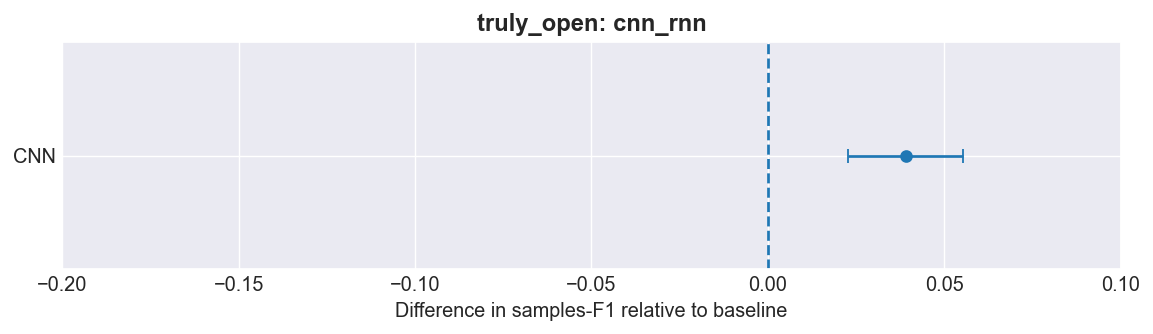

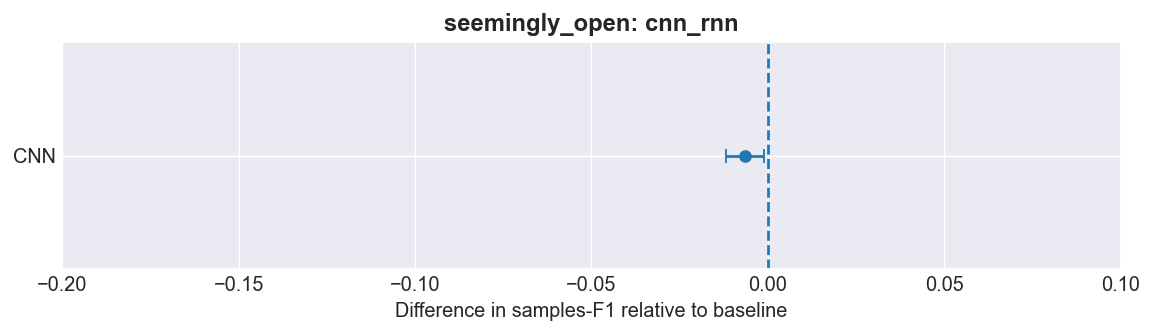

In [118]:
plot_bootstrap_ci(paired_bootstrap, "truly_open", "classic_ml")
plot_bootstrap_ci(paired_bootstrap, "seemingly_open", "classic_ml")
plot_bootstrap_ci(paired_bootstrap, "truly_open", "cnn_rnn")
plot_bootstrap_ci(paired_bootstrap, "seemingly_open", "cnn_rnn")


In [119]:
def plot_transformer_delta(df, question_group):
    data = df[df["question_group"] == question_group].copy()
    data = data.sort_values("delta_samples_f1")

    y = np.arange(len(data))
    x = data["delta_samples_f1"].values
    x_low = data["ci_low"].values
    x_high = data["ci_high"].values
    xerr = np.vstack([x - x_low, x_high - x])

    plt.figure(figsize=(9, 0.7 * len(data) + 2))
    plt.errorbar(x, y, xerr=xerr, fmt="o", capsize=4)
    plt.axvline(0, linestyle="--")
    plt.yticks(y, data["model_name"])
    # plt.xlim(-0.2, 0.3)
    plt.xlabel("Difference in samples-F1 relative to Encoder")
    plt.title(f"{question_group}: transformer models")
    plt.tight_layout()
    plt.show()


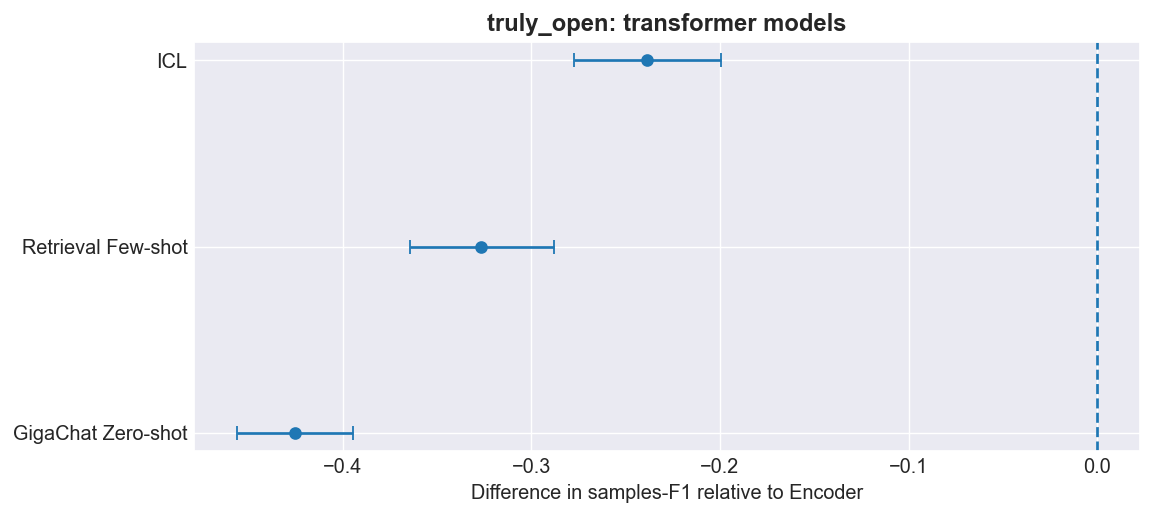

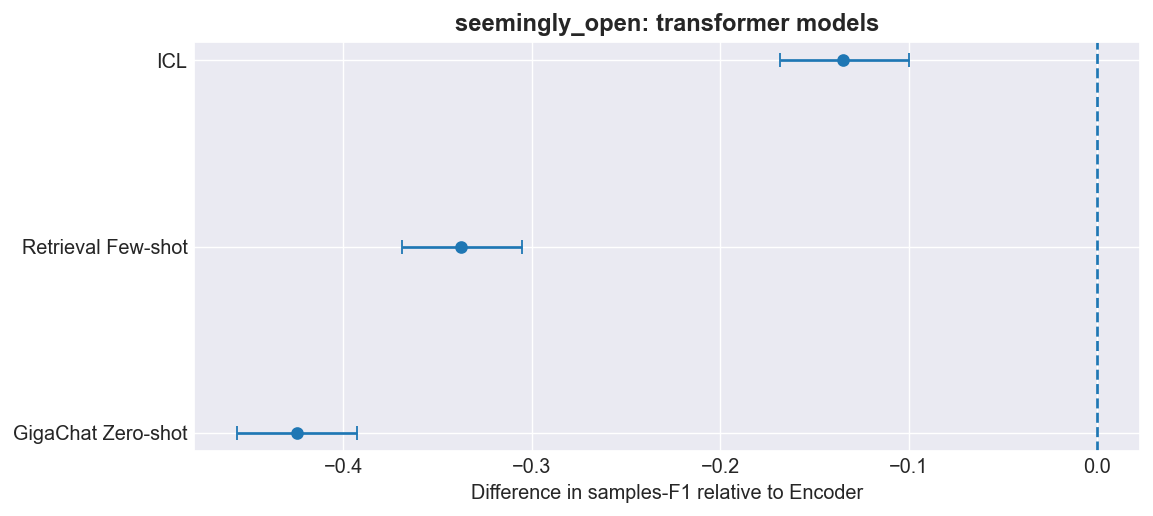

In [120]:
plot_transformer_delta(encoder_gigachat_delta, "truly_open")
plot_transformer_delta(encoder_gigachat_delta, "seemingly_open")
